In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
# ===============================
# CREATE DUMMY PROCUREMENT DATA
# ===============================

suppliers = [
    "PT Alpha Steel",
    "PT Nusantara Plastik",
    "PT Global Chemical",
    "PT Mega Packaging",
    "PT Logistik Prima",
    "PT Sinar Baja",
    "PT Indo Material",
    "PT Central Supply"
]

categories = [
    "Steel",
    "Plastic",
    "Packaging",
    "Chemical",
    "Office Supplies"
]

departments = [
    "Production",
    "Warehouse",
    "Maintenance",
    "Engineering",
    "Office"
]

dates = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
)

records = []

for i in range(500):

    supplier = np.random.choice(suppliers)

    category = np.random.choice(categories)

    department = np.random.choice(departments)

    date = np.random.choice(dates)

    amount = np.random.randint(500000,25000000)

    records.append([
        supplier,
        category,
        department,
        date,
        amount
    ])

df = pd.DataFrame(records,
                  columns=[
                      "Supplier",
                      "Category",
                      "Department",
                      "Date",
                      "Purchase Amount"
                  ])

df.head()

,Supplier,Category,Department,Date,Purchase Amount
0,PT Indo Material,Chemical,Office,2025-09-28,23827850
1,PT Central Supply,Office Supplies,Office,2025-04-13,2734489
2,PT Global Chemical,Packaging,Maintenance,2025-03-29,24481428
3,PT Mega Packaging,Packaging,Office,2025-09-15,14453367
4,PT Mega Packaging,Plastic,Engineering,2025-10-04,1762752


In [ ]:
df.to_csv("procurement_data.csv", index=False)

print("Dataset berhasil dibuat!")

Dataset berhasil dibuat!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Supplier         500 non-null    object        
 1   Category         500 non-null    object        
 2   Department       500 non-null    object        
 3   Date             500 non-null    datetime64[ns]
 4   Purchase Amount  500 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 19.7+ KB


In [ ]:
df.describe()

,Date,Purchase Amount
count,500,5.000000e+02
mean,2025-06-30 22:19:12.000000256,1.279044e+07
min,2025-01-01 00:00:00,5.921930e+05
25%,2025-04-06 18:00:00,6.643585e+06
50%,2025-06-28 00:00:00,1.255262e+07
75%,2025-09-26 12:00:00,1.899349e+07
max,2025-12-31 00:00:00,2.495529e+07
std,NaN,7.099714e+06


In [ ]:
total_spend = df["Purchase Amount"].sum()

print(f"Total Procurement Spend: Rp {total_spend:,.0f}")

Total Procurement Spend: Rp 6,395,218,007


In [ ]:
supplier_spend = (
    df.groupby("Supplier")["Purchase Amount"]
      .sum()
      .sort_values(ascending=False)
)

supplier_spend

,Purchase Amount
Supplier,
PT Nusantara Plastik,1095148111
PT Alpha Steel,995850586
PT Indo Material,876228408
PT Mega Packaging,797911112
PT Global Chemical,780208604
PT Central Supply,734637024
PT Sinar Baja,630123800
PT Logistik Prima,485110362


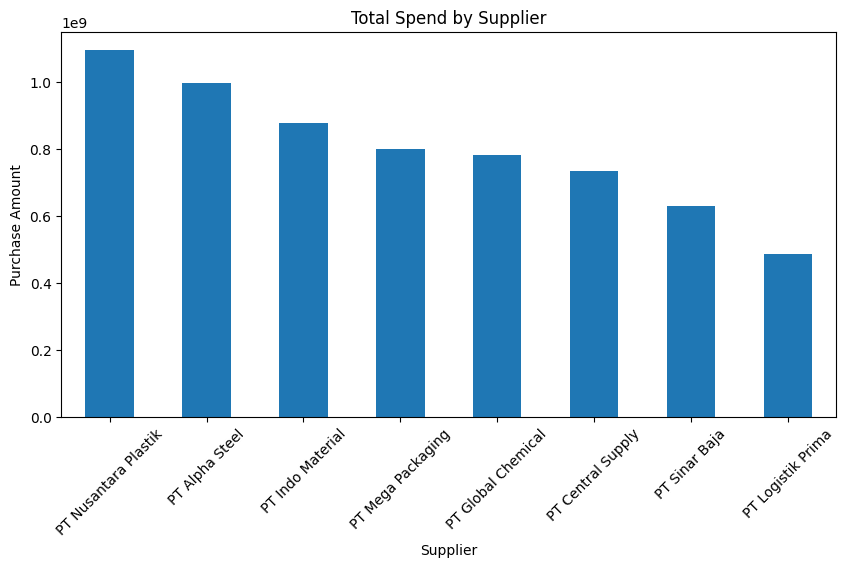

In [ ]:
plt.figure(figsize=(10,5))

supplier_spend.plot(kind="bar")

plt.title("Total Spend by Supplier")

plt.ylabel("Purchase Amount")

plt.xticks(rotation=45)

plt.show()

In [ ]:
category_spend = (
    df.groupby("Category")["Purchase Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(category_spend)

Category
Office Supplies    1391085814
Packaging          1358122346
Steel              1338660665
Plastic            1168274285
Chemical           1139074897
Name: Purchase Amount, dtype: int64


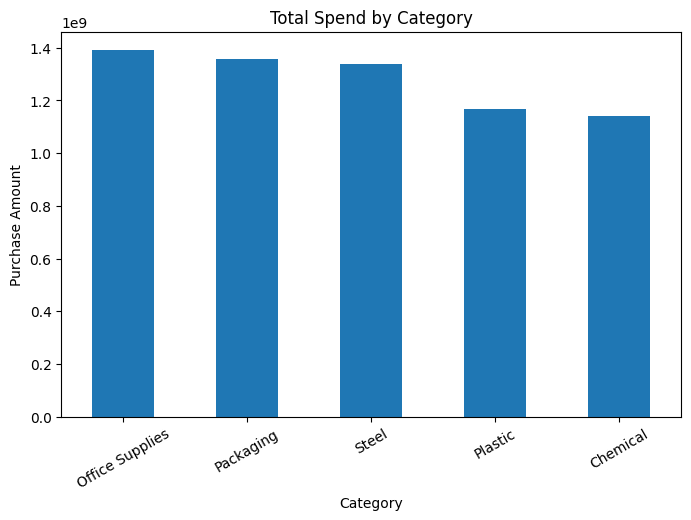

In [ ]:
plt.figure(figsize=(8,5))

category_spend.plot(kind="bar")

plt.title("Total Spend by Category")
plt.xlabel("Category")
plt.ylabel("Purchase Amount")
plt.xticks(rotation=30)

plt.show()

In [ ]:
#Monthly spend trend

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

In [ ]:
monthly_spend = (
    df.groupby("Month")["Purchase Amount"]
      .sum()
)

monthly_spend

,Purchase Amount
Month,
2025-01,580074514
2025-02,364157973
2025-03,485073791
2025-04,570557489
2025-05,520668101
2025-06,687373192
2025-07,563244107
2025-08,474175462
2025-09,586297721


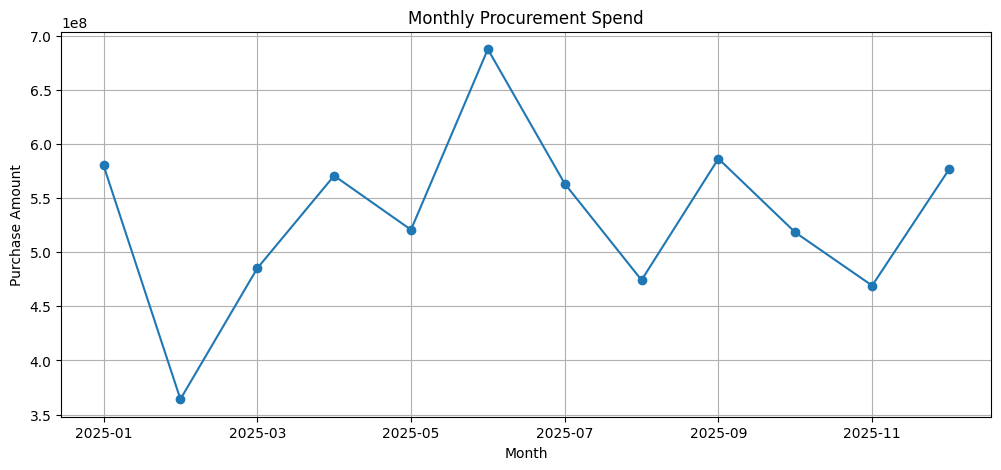

In [ ]:
plt.figure(figsize=(12,5))

monthly_spend.plot(marker="o")

plt.title("Monthly Procurement Spend")
plt.xlabel("Month")
plt.ylabel("Purchase Amount")

plt.grid(True)

plt.show()

In [ ]:
#Top ten purchase transactions

In [ ]:
top10 = df.sort_values(
    by="Purchase Amount",
    ascending=False
).head(10)

top10

,Supplier,Category,Department,Date,Purchase Amount,Month
370,PT Nusantara Plastik,Plastic,Warehouse,2025-06-23,24955289,2025-06
194,PT Central Supply,Office Supplies,Engineering,2025-08-11,24920819,2025-08
75,PT Nusantara Plastik,Packaging,Warehouse,2025-10-15,24890485,2025-10
287,PT Alpha Steel,Plastic,Production,2025-11-07,24876816,2025-11
27,PT Indo Material,Packaging,Production,2025-07-26,24835374,2025-07
49,PT Global Chemical,Office Supplies,Maintenance,2025-05-28,24751131,2025-05
300,PT Indo Material,Packaging,Warehouse,2025-02-03,24742589,2025-02
246,PT Central Supply,Office Supplies,Maintenance,2025-07-30,24710749,2025-07
336,PT Logistik Prima,Office Supplies,Engineering,2025-10-22,24692961,2025-10
141,PT Central Supply,Chemical,Engineering,2025-01-08,24626585,2025-01


In [ ]:
#Procurement KPI

In [ ]:
print("="*40)
print("PROCUREMENT KPI")
print("="*40)

print(f"Total Spend : Rp {df['Purchase Amount'].sum():,.0f}")

print(f"Average Purchase : Rp {df['Purchase Amount'].mean():,.0f}")

print(f"Highest Purchase : Rp {df['Purchase Amount'].max():,.0f}")

print(f"Number of Suppliers : {df['Supplier'].nunique()}")

print(f"Number of Categories : {df['Category'].nunique()}")

print(f"Total Purchase Orders : {len(df)}")

PROCUREMENT KPI
Total Spend : Rp 6,395,218,007
Average Purchase : Rp 12,790,436
Highest Purchase : Rp 24,955,289
Number of Suppliers : 8
Number of Categories : 5
Total Purchase Orders : 500


In [ ]:
#Supplier Contribution

In [ ]:
supplier_percent = (
    supplier_spend /
    supplier_spend.sum()
    *100
).round(2)

supplier_percent

,Purchase Amount
Supplier,
PT Nusantara Plastik,17.12
PT Alpha Steel,15.57
PT Indo Material,13.70
PT Mega Packaging,12.48
PT Global Chemical,12.20
PT Central Supply,11.49
PT Sinar Baja,9.85
PT Logistik Prima,7.59


In [ ]:
supplier_summary = pd.DataFrame({
    "Total Spend": supplier_spend,
    "Contribution (%)": supplier_percent
})

supplier_summary

,Total Spend,Contribution (%)
Supplier,,
PT Nusantara Plastik,1095148111,17.12
PT Alpha Steel,995850586,15.57
PT Indo Material,876228408,13.70
PT Mega Packaging,797911112,12.48
PT Global Chemical,780208604,12.20
PT Central Supply,734637024,11.49
PT Sinar Baja,630123800,9.85
PT Logistik Prima,485110362,7.59


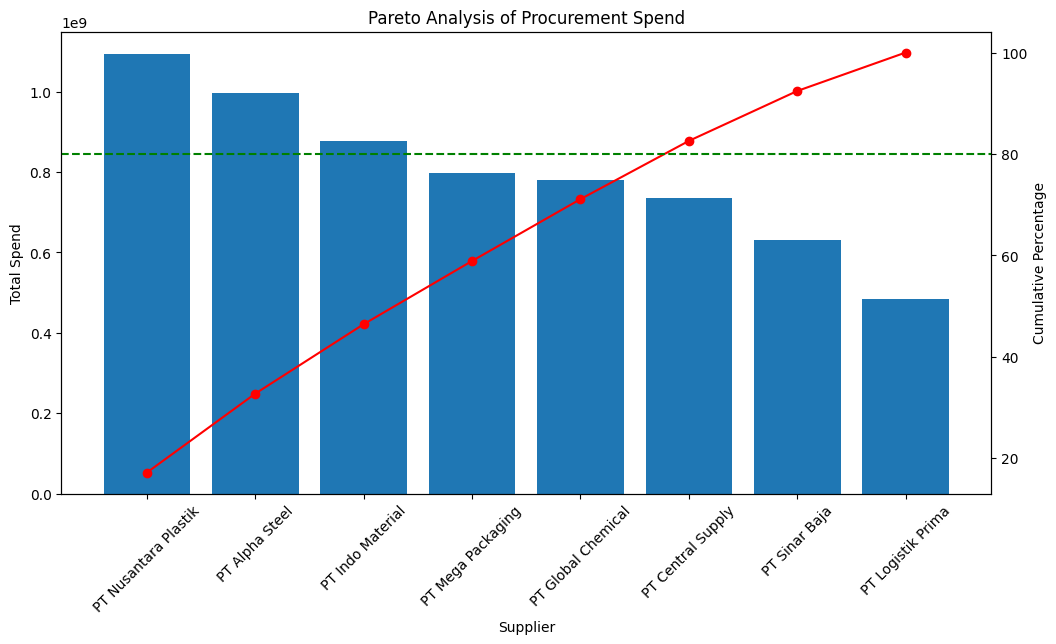

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar Chart
ax1.bar(
    pareto["Supplier"],
    pareto["Total Spend"]
)

ax1.set_ylabel("Total Spend")
ax1.set_xlabel("Supplier")

plt.xticks(rotation=45)

# Line Chart
ax2 = ax1.twinx()

ax2.plot(
    pareto["Supplier"],
    pareto["Cumulative %"],
    color="red",
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage")

ax2.axhline(
    80,
    color="green",
    linestyle="--"
)

plt.title("Pareto Analysis of Procurement Spend")

plt.show()

In [24]:
top_supplier = pareto.iloc[0]

print("="*50)
print("BUSINESS INSIGHT")
print("="*50)

print(f"Top Supplier : {top_supplier['Supplier']}")

print(f"Spend : Rp {top_supplier['Total Spend']:,.0f}")

print(f"Contribution : {top_supplier['Cumulative %']:.2f}% cumulative")

BUSINESS INSIGHT
Top Supplier : PT Nusantara Plastik
Spend : Rp 1,095,148,111
Contribution : 17.12% cumulative


In [25]:
#Supplier Ranking
pareto["Rank"] = range(1, len(pareto)+1)

pareto

,Supplier,Total Spend,Cumulative Spend,Cumulative %,Rank
0,PT Nusantara Plastik,1095148111,1095148111,17.124484,1
1,PT Alpha Steel,995850586,2090998697,32.696285,2
2,PT Indo Material,876228408,2967227105,46.397591,3
3,PT Mega Packaging,797911112,3765138217,58.874275,4
4,PT Global Chemical,780208604,4545346821,71.074150,5
5,PT Central Supply,734637024,5279983845,82.561436,6
6,PT Sinar Baja,630123800,5910107645,92.414483,7
7,PT Logistik Prima,485110362,6395218007,100.000000,8


In [26]:
 pareto.to_excel(
    "Supplier_Spend_Report.xlsx",
    index=False
)

print("Report berhasil disimpan.")

Report berhasil disimpan.


In [27]:
from google.colab import files

files.download("Supplier_Spend_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

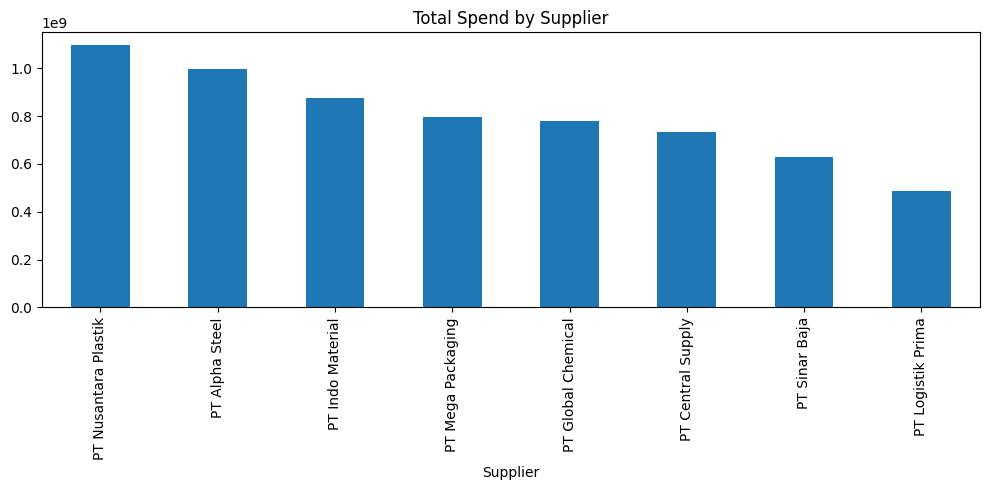

In [28]:
plt.figure(figsize=(10,5))

supplier_spend.plot(kind="bar")

plt.title("Total Spend by Supplier")

plt.tight_layout()

plt.savefig(
    "supplier_spend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

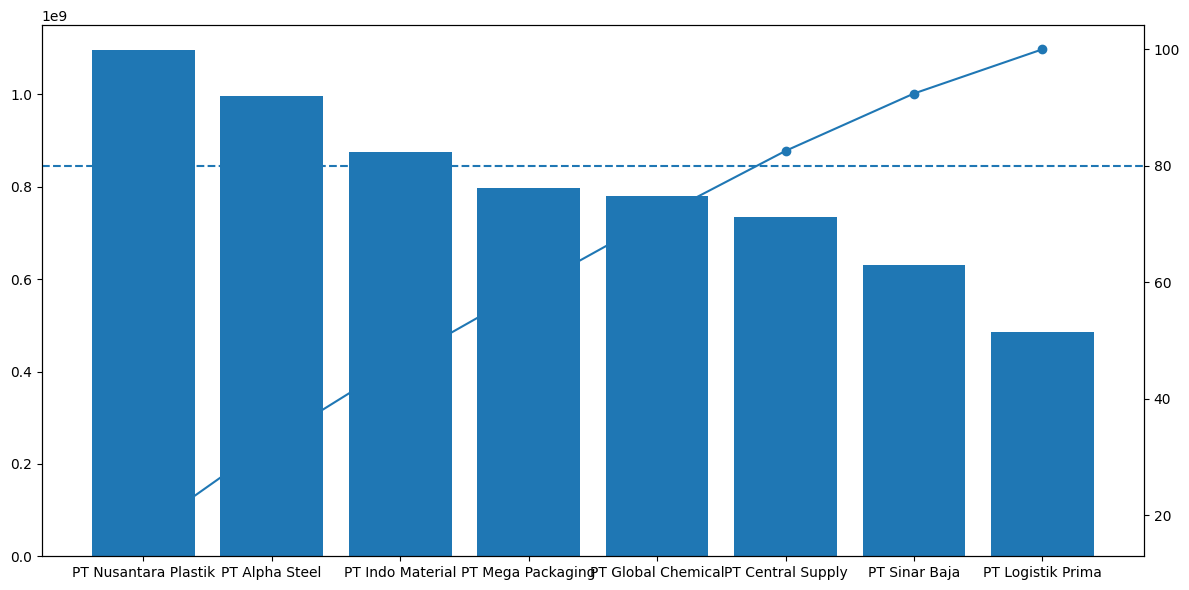

In [29]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    pareto["Supplier"],
    pareto["Total Spend"]
)

ax2 = ax1.twinx()

ax2.plot(
    pareto["Supplier"],
    pareto["Cumulative %"],
    marker="o"
)

ax2.axhline(80, linestyle="--")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()